<a href="https://colab.research.google.com/github/doanthuchuyen/thuchuyen07.github.io/blob/gh-pages/BT04_ex1_FeatureEngineering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler, PolynomialFeatures
from sklearn.decomposition import PCA, FastICA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

In [2]:
iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = iris.target

In [3]:
X.columns = ['SL', 'SW', 'PL', 'PW']

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print(f"Kích thước tập huấn luyện: {X_train.shape}")
print(f"Kích thước tập kiểm thử: {X_test.shape}")
print("-" * 50)

Kích thước tập huấn luyện: (105, 4)
Kích thước tập kiểm thử: (45, 4)
--------------------------------------------------


In [5]:
classifier = KNeighborsClassifier(n_neighbors=5)

In [6]:
classifier.fit(X_train, y_train)
base_accuracy = accuracy_score(classifier.predict(X_test), y_test)
print(f"Độ chính xác Cơ sở (chưa biến đổi): {base_accuracy:.4f}")
print("-" * 50)

Độ chính xác Cơ sở (chưa biến đổi): 1.0000
--------------------------------------------------


In [7]:
scaler = MinMaxScaler()

In [9]:
pipeline_pca = Pipeline(steps=[
    ('scaler', scaler),
    ('pca', PCA(n_components=2)),
    ('knn', classifier)
])
pipeline_pca.fit(X_train, y_train)
pca_accuracy = accuracy_score(pipeline_pca.predict(X_test), y_test)
print(f"Độ chính xác sau khi dùng PCA: {pca_accuracy:.4f}")

Độ chính xác sau khi dùng PCA: 0.9556


In [10]:
pipeline_ica = Pipeline(steps=[
    ('scaler', scaler),
    ('ica', FastICA(n_components=2, random_state=42, max_iter=1000)),
    ('knn', classifier)
])

pipeline_ica.fit(X_train, y_train)
ica_accuracy = accuracy_score(pipeline_ica.predict(X_test), y_test)
print(f"Độ chính xác sau khi dùng ICA: {ica_accuracy:.4f}")

Độ chính xác sau khi dùng ICA: 0.9778


In [11]:
scaler_poly = StandardScaler()
poly_features = PolynomialFeatures(degree=3, include_bias=False)

pipeline_poly = Pipeline(steps=[
    ('scaler', scaler_poly),
    ('poly', poly_features),
    ('knn', classifier)
])

pipeline_poly.fit(X_train, y_train)
poly_accuracy = accuracy_score(pipeline_poly.predict(X_test), y_test)
print(f"Độ chính xác sau khi dùng PolynomialFeatures (bậc 3): {poly_accuracy:.4f}")
print("-" * 50)

Độ chính xác sau khi dùng PolynomialFeatures (bậc 3): 1.0000
--------------------------------------------------


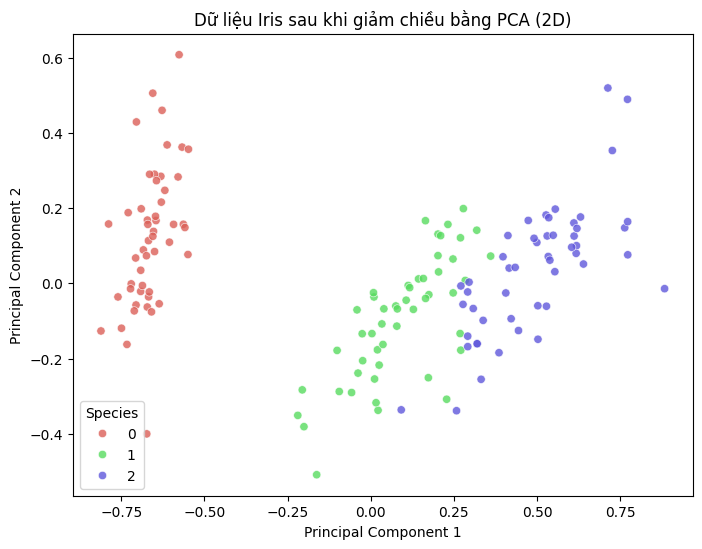

In [12]:
pca_transformer = pipeline_pca.named_steps['pca']
X_pca = pca_transformer.transform(pipeline_pca.named_steps['scaler'].transform(X))
df_pca = pd.DataFrame(data=X_pca, columns=['Principal Component 1', 'Principal Component 2'])
df_pca['Species'] = iris.target

plt.figure(figsize=(8, 6))
sns.scatterplot(
    x='Principal Component 1',
    y='Principal Component 2',
    hue='Species',
    data=df_pca,
    palette=sns.color_palette("hls", 3),
    legend='full',
    alpha=0.8
)
plt.title('Dữ liệu Iris sau khi giảm chiều bằng PCA (2D)')
plt.show()